# Dual graph explainer

Three panels: (1) a rectangle partitioned into cells, (2) its rook dual graph, (3) its queen dual graph.

Built from a regular grid of `shapely` box polygons so adjacency rules are easy to see.

In [80]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from shapely.geometry import box
import geopandas as gpd
import gerrychain

In [81]:
NROWS, NCOLS = 2, 2
CELL_W, CELL_H = 1.0, 1.0

cells = {}
centroids = {}
for r in range(NROWS):
    for c in range(NCOLS):
        key = (r, c)
        # print(key)
        cells[key] = box(c * CELL_W, r * CELL_H,
                         (c + 1) * CELL_W, (r + 1) * CELL_H)
        centroids[key] = (c * CELL_W + CELL_W / 2,
                          r * CELL_H + CELL_H / 2)

In [82]:
# add a longer polygon
c = 2
r = 0
cells[(r, c)] = box(c * CELL_W, r * CELL_H,
                    (c + 1) * CELL_W, (r + 2) * CELL_H)
centroids[key] = (c * CELL_W + CELL_W / 2,
                  0.5 * CELL_H + CELL_H / 2)

In [83]:
gdf = gpd.GeoDataFrame(geometry=list(cells.values()))
G_rook = gerrychain.Graph.from_geodataframe(gdf) # rook by default
G_rook

G_queen = gerrychain.Graph.from_geodataframe(gdf, adjacency='queen')
G_queen

/Users/maria/Library/Caches/pypoetry/virtualenvs/capy-NsKqgI8c-py3.13/lib/python3.13/site-packages/gerrychain/graph/graph.py:275: UserWarning: GeoDataFrame has no CRS. Did you forget to set it? If you're sure this is correct, you can ignore this warning. Otherwise, please set the CRS using the `crs_override` parameter. Attempting to proceed without a CRS.
  warnings.warn(
/Users/maria/Library/Caches/pypoetry/virtualenvs/capy-NsKqgI8c-py3.13/lib/python3.13/site-packages/gerrychain/graph/graph.py:275: UserWarning: GeoDataFrame has no CRS. Did you forget to set it? If you're sure this is correct, you can ignore this warning. Otherwise, please set the CRS using the `crs_override` parameter. Attempting to proceed without a CRS.
  warnings.warn(


<Graph [5 nodes, 8 edges]>

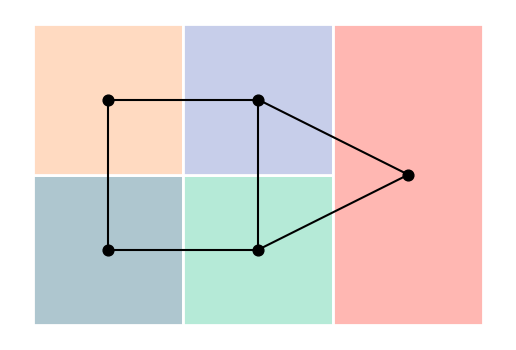

In [ ]:
pos = {i: (gdf.geometry[i].centroid.x, gdf.geometry[i].centroid.y)
       for i in G_rook.nodes()}

gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2)
nx.draw(G_rook, pos=pos,
        node_size=60, node_color="black", edge_color="black", width=1.5)


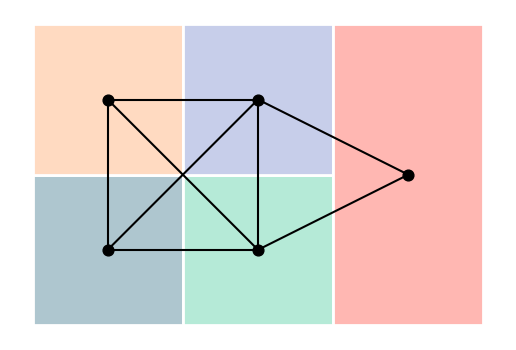

In [61]:
pos = {i: (gdf.geometry[i].centroid.x, gdf.geometry[i].centroid.y)
       for i in G_rook.nodes()}

gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2)
nx.draw(G_queen, pos=pos,
        node_size=60, node_color="black", edge_color="black", width=1.5)

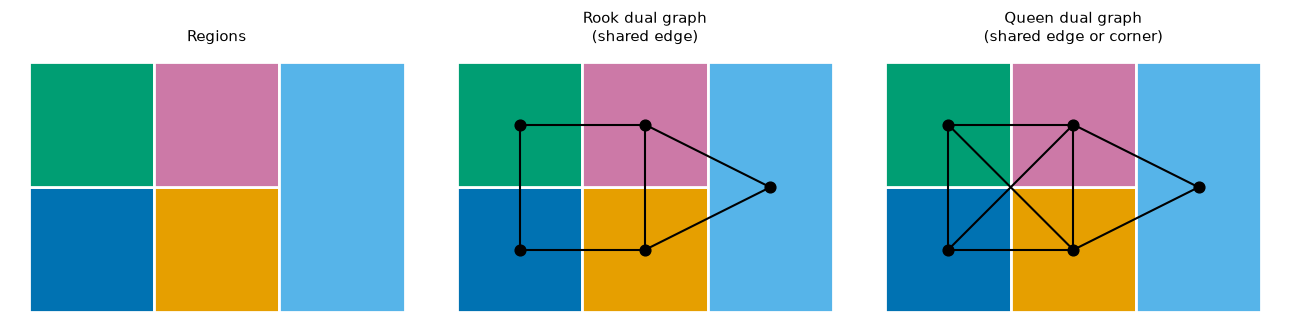

In [84]:
# fill colours for the cells (cycle over a small palette)


FILL_COLORS = ["#0072b2",  # blue
    "#e69f00",  # amber
    "#009e73",  # green
    "#cc79a7",  # mauve
    "#56b4e9",  # sky
    "#d55e00",  # vermillion
    "#c3ba32",  # yellow
    "#000000",  # black
    "#999999",  # gray
    "#871769"]

NODE_COLOR  = "#333333"
EDGE_COLOR  = "#333333"
# CORNER_COLOR = "#e69f00" # queen-only (corner) edges highlighted

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
pos = {i: (gdf.geometry[i].centroid.x, gdf.geometry[i].centroid.y)
       for i in G_rook.nodes()}

# panel 1 — regions only
gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2, ax=axes[0])
axes[0].set_title("Regions", fontsize=11)
axes[0].axis('off')

# panel 2 — rook dual graph
gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2, ax=axes[1])
nx.draw(G_rook, pos=pos, ax=axes[1],
        node_size=60, node_color="black", edge_color="black", width=1.5)
axes[1].set_title("Rook dual graph\n(shared edge)", fontsize=11)

# panel 3 — queen dual graph (rook edges + corner edges highlighted)
gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2, ax=axes[2])
nx.draw(G_queen, pos=pos, ax=axes[2],
        node_size=60, node_color="black", edge_color="black", width=1.5)
axes[2].set_title("Queen dual graph\n(shared edge or corner)", fontsize=11)

plt.tight_layout()
plt.show()

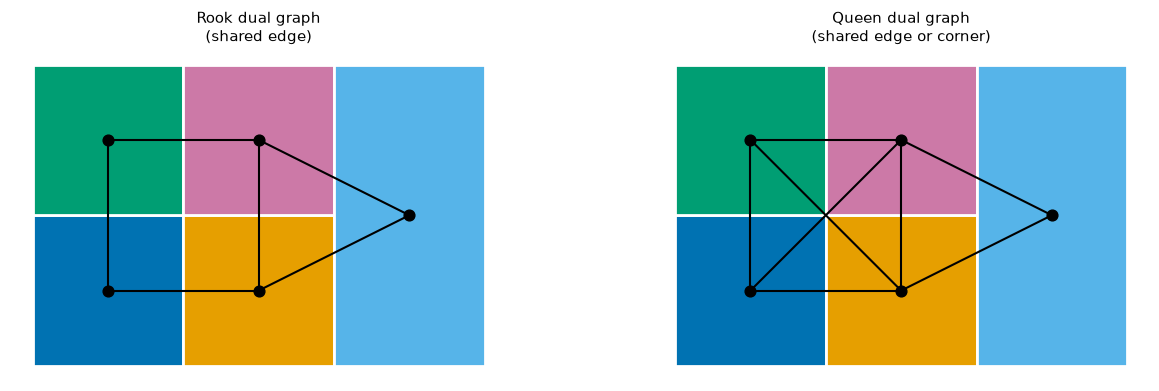

In [86]:
FILL_COLORS = ["#0072b2",  # blue
    "#e69f00",  # amber
    "#009e73",  # green
    "#cc79a7",  # mauve
    "#56b4e9",  # sky
    "#d55e00",  # vermillion
    "#c3ba32",  # yellow
    "#000000",  # black
    "#999999",  # gray
    "#871769"]

NODE_COLOR  = "#333333"
EDGE_COLOR  = "#333333"
# CORNER_COLOR = "#e69f00" # queen-only (corner) edges highlighted

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pos = {i: (gdf.geometry[i].centroid.x, gdf.geometry[i].centroid.y)
       for i in G_rook.nodes()}

# panel 2 — rook dual graph
gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2, ax=axes[0])
nx.draw(G_rook, pos=pos, ax=axes[0],
        node_size=60, node_color="black", edge_color="black", width=1.5)
axes[0].set_title("Rook dual graph\n(shared edge)", fontsize=11)

# panel 3 — queen dual graph (rook edges + corner edges highlighted)
gdf.plot(color=FILL_COLORS[:len(gdf)], edgecolor="white", linewidth=2, ax=axes[1])
nx.draw(G_queen, pos=pos, ax=axes[1],
        node_size=60, node_color="black", edge_color="black", width=1.5)
axes[1].set_title("Queen dual graph\n(shared edge or corner)", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:


# # build shapely boxes and their centroid positions
# cells = {}
# centroids = {}
# for r in range(NROWS):
#     for c in range(NCOLS):
#         key = (r, c)
#         cells[key] = box(c * CELL_W, r * CELL_H,
#                          (c + 1) * CELL_W, (r + 1) * CELL_H)
#         centroids[key] = (c * CELL_W + CELL_W / 2,
#                           r * CELL_H + CELL_H / 2)

# def rook_neighbors(r, c):
#     """Cells sharing a full edge (cardinal directions)."""
#     for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
#         nr, nc = r + dr, c + dc
#         if 0 <= nr < NROWS and 0 <= nc < NCOLS:
#             yield (nr, nc)

# def queen_neighbors(r, c):
#     """Cells sharing an edge or corner (8 directions)."""
#     for dr in [-1, 0, 1]:
#         for dc in [-1, 0, 1]:
#             if dr == 0 and dc == 0:
#                 continue
#             nr, nc = r + dr, c + dc
#             if 0 <= nr < NROWS and 0 <= nc < NCOLS:
#                 yield (nr, nc)

# def unique_edges(neighbor_fn):
#     """Return deduplicated edge list as pairs of centroid coordinates."""
#     seen = set()
#     edges = []
#     for r in range(NROWS):
#         for c in range(NCOLS):
#             for nb in neighbor_fn(r, c):
#                 key = tuple(sorted([(r, c), nb]))
#                 if key not in seen:
#                     seen.add(key)
#                     edges.append((centroids[(r, c)], centroids[nb]))
#     return edges

# rook_edges = unique_edges(rook_neighbors)
# queen_edges = unique_edges(queen_neighbors)
# # edges present in queen but not rook (the corner connections)
# rook_edge_set = set(map(tuple, map(sorted, [(a, b) for a, b in rook_edges])))
# corner_edges  = [e for e in queen_edges
#                  if tuple(sorted([e[0], e[1]])) not in rook_edge_set]

[((0.5, 0.5), (0.5, 1.5)),
 ((0.5, 0.5), (1.5, 0.5)),
 ((1.5, 0.5), (1.5, 1.5)),
 ((1.5, 0.5), (2.5, 0.5)),
 ((2.5, 0.5), (2.5, 1.5)),
 ((2.5, 0.5), (3.5, 0.5)),
 ((3.5, 0.5), (3.5, 1.5)),
 ((0.5, 1.5), (0.5, 2.5)),
 ((0.5, 1.5), (1.5, 1.5)),
 ((1.5, 1.5), (1.5, 2.5)),
 ((1.5, 1.5), (2.5, 1.5)),
 ((2.5, 1.5), (2.5, 2.5)),
 ((2.5, 1.5), (3.5, 1.5)),
 ((3.5, 1.5), (3.5, 2.5)),
 ((0.5, 2.5), (1.5, 2.5)),
 ((1.5, 2.5), (2.5, 2.5)),
 ((2.5, 2.5), (3.5, 2.5))]

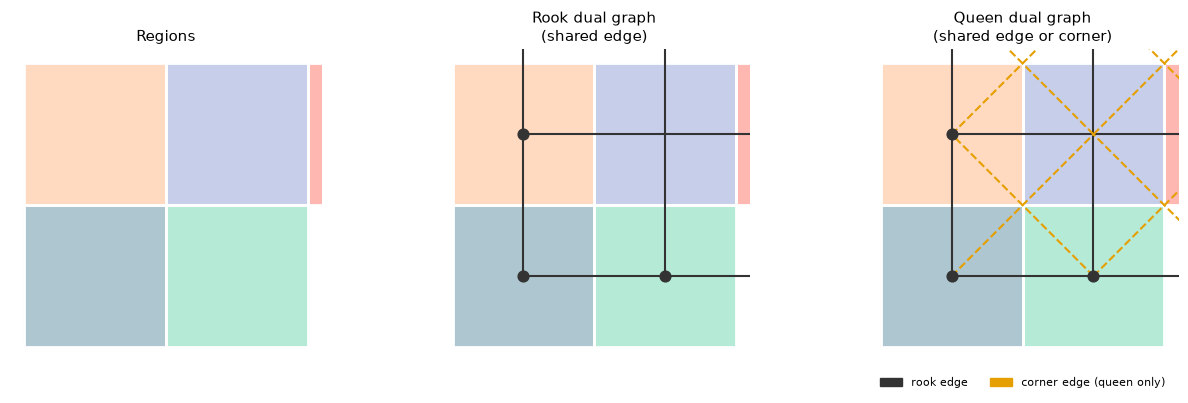

In [ ]:
# # pastel fill colours for the cells (cycle over a small palette)
# FILL_COLORS = ["#aec6cf", "#b5ead7", "#ffdac1", "#c7ceea",
#                "#ffb7b2", "#e2f0cb", "#f8cdd0", "#d4a5a5"]

# NODE_COLOR  = "#333333"
# EDGE_COLOR  = "#333333"
# CORNER_COLOR = "#e69f00"   # queen-only (corner) edges highlighted

# def draw_regions(ax):
#     for i, ((r, c), poly) in enumerate(cells.items()):
#         x, y = poly.exterior.xy
#         ax.fill(x, y, color=FILL_COLORS[i % len(FILL_COLORS)], zorder=0)
#         ax.plot(x, y, color="white", lw=2, zorder=1)
#     ax.set_xlim(-0.1, NCOLS + 0.1)
#     ax.set_ylim(-0.1, NROWS + 0.1)
#     ax.set_aspect("equal")
#     ax.axis("off")

# def draw_graph(ax, edges, extra_edges=None):
#     draw_regions(ax)
#     # base edges
#     lc = LineCollection(edges, colors=EDGE_COLOR, linewidths=1.5, zorder=2)
#     ax.add_collection(lc)
#     # optional extra edges (corner connections) in a different colour
#     if extra_edges:
#         lc2 = LineCollection(extra_edges, colors=CORNER_COLOR,
#                              linewidths=1.5, linestyles="--", zorder=2)
#         ax.add_collection(lc2)
#     # nodes at centroids
#     xs, ys = zip(*centroids.values())
#     ax.scatter(xs, ys, s=60, color=NODE_COLOR, zorder=3)

# fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# # panel 1 — regions only
# draw_regions(axes[0])
# axes[0].set_title("Regions", fontsize=11)

# # panel 2 — rook dual graph
# draw_graph(axes[1], rook_edges)
# axes[1].set_title("Rook dual graph\n(shared edge)", fontsize=11)

# # panel 3 — queen dual graph (rook edges + corner edges highlighted)
# draw_graph(axes[2], rook_edges, extra_edges=corner_edges)
# axes[2].set_title("Queen dual graph\n(shared edge or corner)", fontsize=11)
# # legend for the corner edges
# axes[2].legend(
#     handles=[
#         mpatches.Patch(color=EDGE_COLOR,   label="rook edge"),
#         mpatches.Patch(color=CORNER_COLOR, label="corner edge (queen only)"),
#     ],
#     loc="lower center", bbox_to_anchor=(0.5, -0.12),
#     ncol=2, fontsize=8, frameon=False,
# )

# plt.tight_layout()
# plt.show()